In [ ]:
import numpy as np
import qiskit
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [ ]:
# First choose the bits to send. For example, let's say we want to send the bits "10". Currently, we will hardcode these bits, later in the notebook we will generate them randomly.
c = "1"
d = "0"

In [ ]:
# Create a quantum circuit with 2 qubits 
protocol = QuantumCircuit(2)

# Create an entangled pair of qubits (Bell state)
protocol.h(0)
protocol.cx(0, 1)
protocol.barrier()

# Operations performed by Alice based on the bits she wants to send
if c == "1":
    protocol.x(0)
if d == "1":
    protocol.z(0)
protocol.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

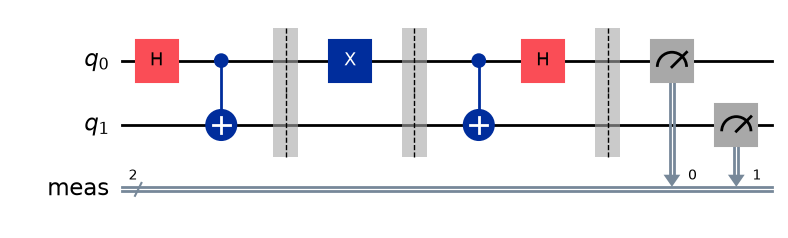

In [ ]:
# Operations performed by Bob to decode the message
protocol.cx(0, 1)
protocol.h(0)
protocol.measure_all()

protocol.draw("mpl")


Outcome: 10, Frequency: 1024


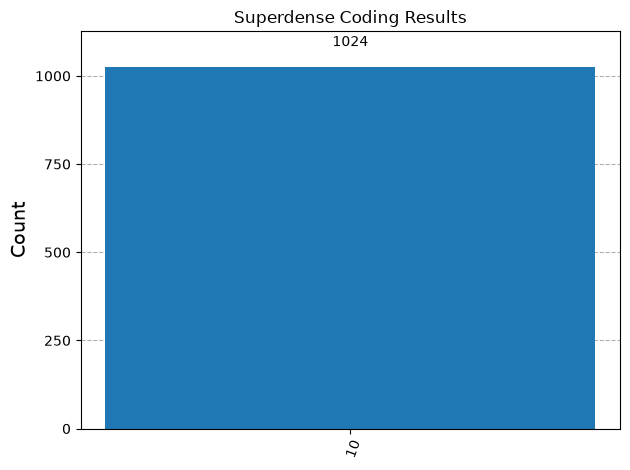

In [ ]:
# Run the protocol on a simulator and get the results
result = AerSimulator().run(protocol).result()
stastics = result.get_counts()

for outcome, frequency in stastics.items():
    print(f"Outcome: {outcome}, Frequency: {frequency}")
    
display(plot_histogram(stastics, title="Superdense Coding Results"))

The measurement results after running the hardcoded circuit 1024 times.

The bar shows a 100% frequency (1024/1024) for the outcome 10. This proves the protocol works perfectly; Alice encoded c=1 and d=0, and Bob accurately decoded and measured 10 without any errors.

In [ ]:
# Now we will modify the circuit to generate random bits for Alice to send. We will use a quantum register to generate a random bit and then use that bit to determine which operations Alice performs on her qubit.
random_bit_generator = QuantumRegister(1, "coin")
ebit0 = QuantumRegister(1, "Alice")
ebit1 = QuantumRegister(1, "Bob")

alice_c = ClassicalRegister(1, "Alice c")
alice_d = ClassicalRegister(1, "Alice d")

demo_circuit = QuantumCircuit(random_bit_generator, ebit0, ebit1, alice_d, alice_c)


In [ ]:
# Create an entangled pair of qubits (Bell state)
demo_circuit.h(ebit0)
demo_circuit.cx(ebit0, ebit1)
demo_circuit.barrier()

# Generate random bits for Alice to send
demo_circuit.h(random_bit_generator)
demo_circuit.measure(random_bit_generator, alice_c)
demo_circuit.h(random_bit_generator)
demo_circuit.measure(random_bit_generator, alice_d)
demo_circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "coin"), index=0>, <Qubit register=(1, "Alice"), index=0>, <Qubit register=(1, "Bob"), index=0>), clbits=())

In [ ]:
# Operations performed by Alice based on the random bits she generated
with demo_circuit.if_test((alice_d, 1), label="Z"):
    demo_circuit.z(ebit0)
with demo_circuit.if_test((alice_c, 1), label="X"):
    demo_circuit.x(ebit0)
demo_circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=3, num_clbits=0, params=[]), qubits=(<Qubit register=(1, "coin"), index=0>, <Qubit register=(1, "Alice"), index=0>, <Qubit register=(1, "Bob"), index=0>), clbits=())

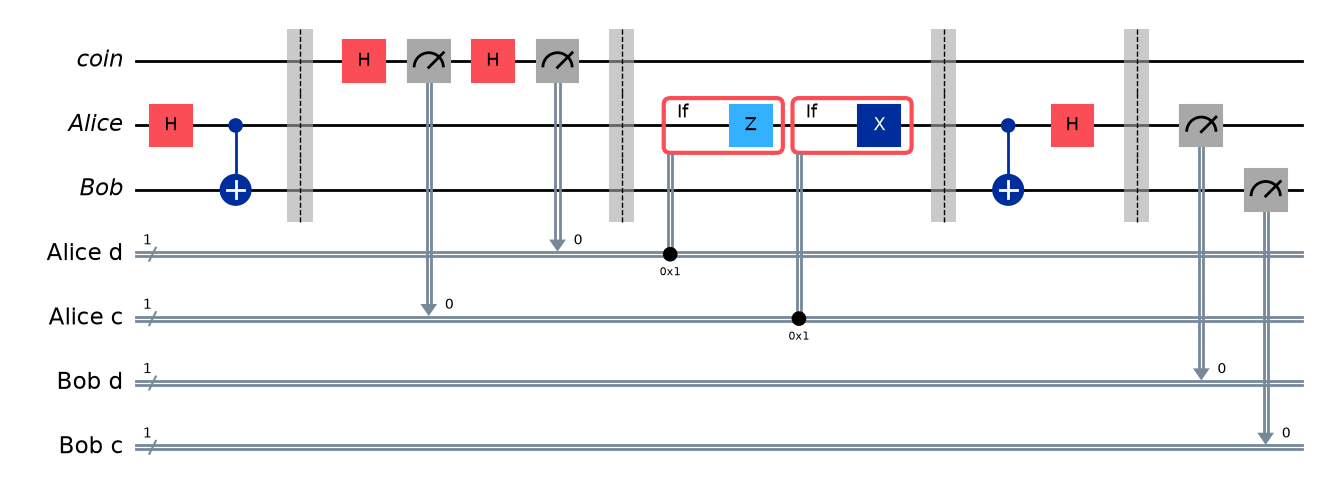

In [ ]:
# Operations performed by Bob to decode the message
demo_circuit.cx(ebit0, ebit1)
demo_circuit.h(ebit0)
demo_circuit.barrier()

# Create classical registers for Bob's measurements
bob_c = ClassicalRegister(1, "Bob c")
bob_d = ClassicalRegister(1, "Bob d")
demo_circuit.add_register(bob_d)
demo_circuit.add_register(bob_c)

demo_circuit.measure(ebit0, bob_d)
demo_circuit.measure(ebit1, bob_c)

display(demo_circuit.draw("mpl"))

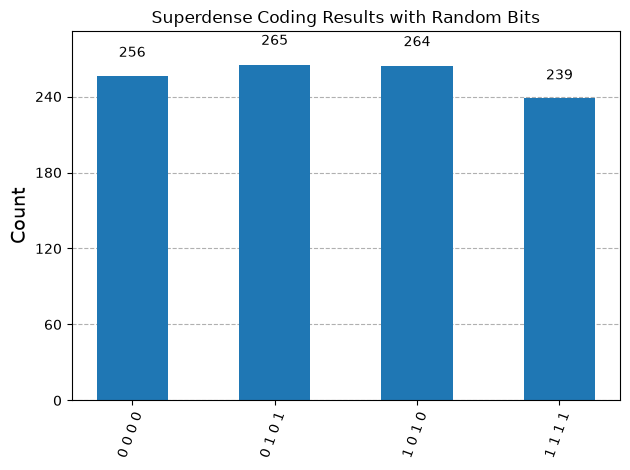

In [ ]:
# Run the modified protocol on a simulator and get the results
results = AerSimulator().run(demo_circuit).result()
stastics = results.get_counts()

display(plot_histogram(stastics, title="Superdense Coding Results with Random Bits"))

The measurement results of the randomized circuit over 1024 shots.
Because Alice's message is randomly generated, there is a roughly 25% chance for each of the four possible messages (00, 01, 10, 11).
The format you represents (Bob_c)(Bob_d)(Alice_c)(Alice_d).

In the outcomes (0000, 0110, 1001, 1111), the first half of the string always matches the second half of the string. For example, in 1001, Alice generated 01 and Bob received 01. This perfectly uniform matching proves that Bob always receives exactly what Alice sent, regardless of what the random message was.